<a href="https://colab.research.google.com/github/Kyle-B3/Type_Knight_Test/blob/main/kylwboma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Goals

* Treat written text as operational data and quantify author/style differences.

* Compare word-frequency profiles (same author across two works; two different authors).

* Identify “author-preferred” words like terms disproportionately used by one author vs another.

* (Optional/extra) Probe a single word’s behavior. Does its rate differ across books/authors, and is that difference statistically significant?


---

Potential Data sources

* Mary W. Shelley — Frankenstein; or, The Modern Prometheus (eBook #84) Project Gutenberg

* Arthur Conan Doyle — The Adventures of Sherlock Holmes (eBook #1661) Project Gutenberg

* Arthur Conan Doyle — The Hound of the Baskervilles (eBook #2852) Project Gutenberg


---


Cleaning & preprocessing

* Fetch text (e.g., requests.get(url).text).

* Strip Gutenberg headers/footers (between the “*** START/END OF THE PROJECT GUTENBERG EBOOK ***” markers).

* Normalize: lowercase, remove punctuation/digits, collapse whitespace; handle curly quotes/emdashes.

* Tokenize into words; remove stopwords; optionally stem/lemmatize (document your choice).

Compare Same Author: The Adventures of Sherlock Holmes vs The Hound of the Baskervilles
Compare: The Adventures of Sherlock Holmes vs The Hound of the Baskervilles
Words more common in 'The Adventures of Sherlock Holmes':
Word  Freq1  Freq2  Difference
 the   5630   3345        2285
   i   3003   1468        1535
 and   3018   1629        1389
  to   2744   1409        1335
   a   2643   1311        1332
  of   2655   1602        1053
  in   1766    912         854
  it   1701    982         719
 you   1481    827         654
that   1744   1134         610

Words more common in 'The Hound of the Baskervilles':
       Word  Freq1  Freq2  Difference
        sir     77    351         274
       moor      0    163         163
      henry     10    147         137
baskerville      0    113         113
   mortimer      0     87          87
  stapleton      0     85          85
         dr     29    110          81
      hound      2     72          70
    charles      1     70          69
  

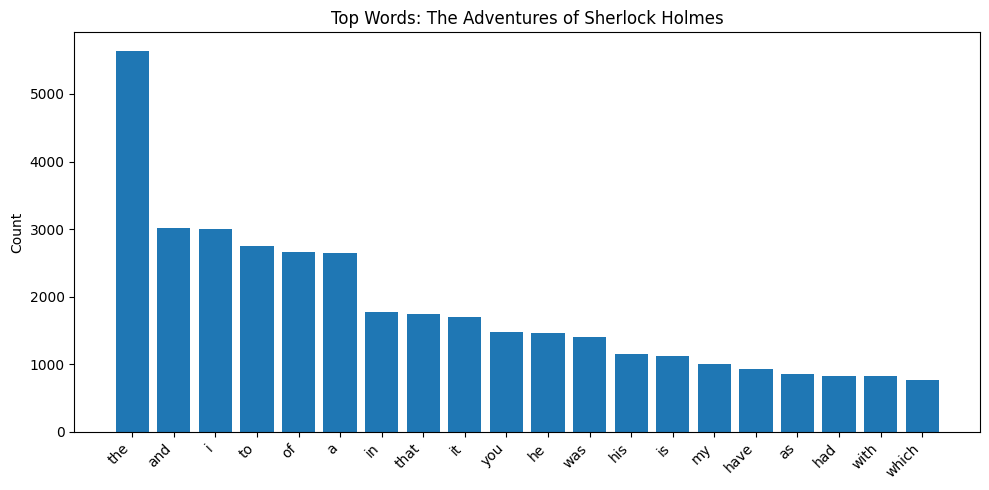

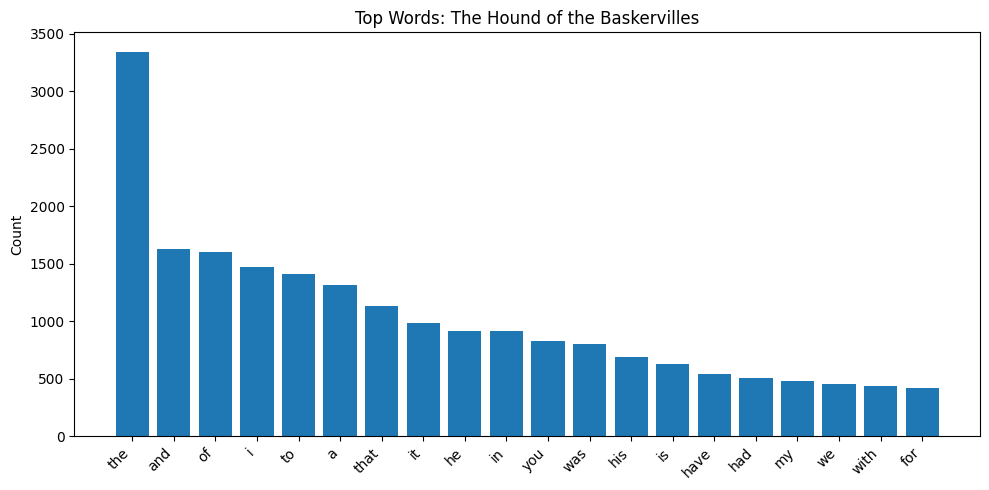

Compare Different Authors: Frankenstein; or, The Modern Prometheus vs The Adventures of Sherlock Holmes
Compare: Frankenstein; or, The Modern Prometheus vs The Adventures of Sherlock Holmes
Words more common in 'Frankenstein; or, The Modern Prometheus':
     Word  Freq1  Freq2  Difference
       my   1776   1007         769
       me    868    635         233
       by    461    349         112
    their    186     97          89
elizabeth     88      0          88
       on    460    380          80
 feelings     76      1          75
    these    154     80          74
  towards     94     20          74
     life    115     48          67

Words more common in 'The Adventures of Sherlock Holmes':
Word  Freq1  Freq2  Difference
 the   4195   5630        1435
   a   1391   2643        1252
  it    547   1701        1154
 you    574   1481         907
  he    608   1467         859
  is    307   1124         817
that   1017   1744         727
  to   2094   2744         650
  in   1129 

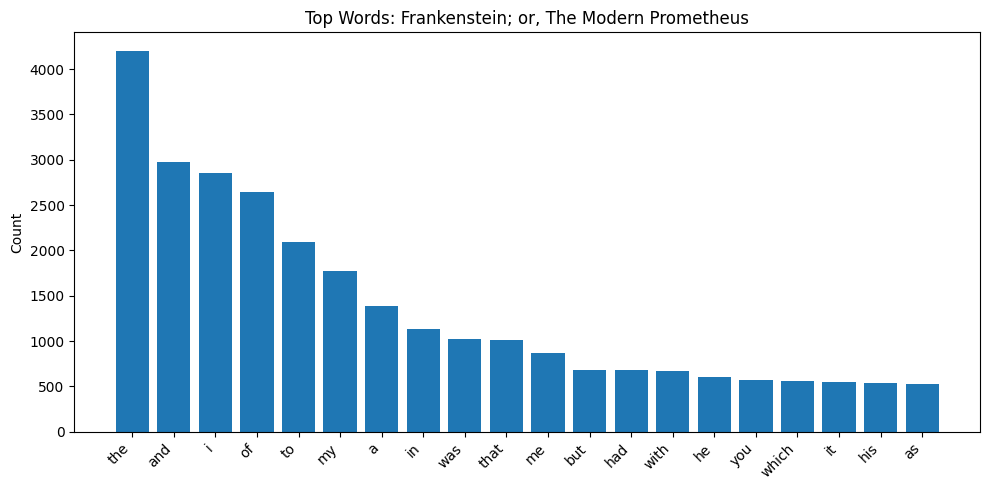

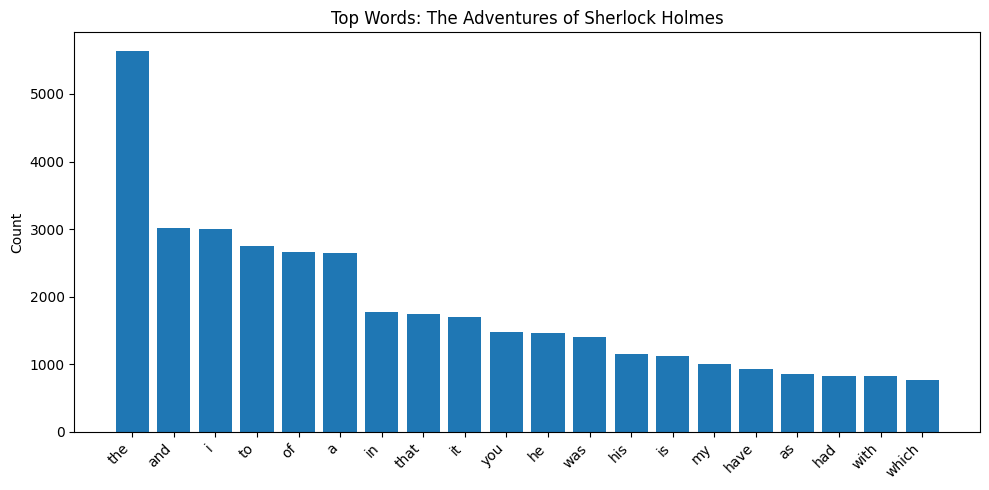

Compare Different Authors: Frankenstein; or, The Modern Prometheus vs The Hound of the Baskervilles
Compare: Frankenstein; or, The Modern Prometheus vs The Hound of the Baskervilles
Words more common in 'Frankenstein; or, The Modern Prometheus':
Word  Freq1  Freq2  Difference
   i   2850   1468        1382
 and   2976   1629        1347
  my   1776    480        1296
  of   2642   1602        1040
 the   4195   3345         850
  to   2094   1409         685
  me    868    326         542
 but    687    400         287
  by    461    213         248
with    667    441         226

Words more common in 'The Hound of the Baskervilles':
  Word  Freq1  Freq2  Difference
    it    547    982         435
   sir      7    351         344
    is    307    624         317
    he    608    914         306
    we    174    453         279
   you    574    827         253
 there     81    299         218
  upon    126    315         189
holmes      0    187         187
  have    365    542        

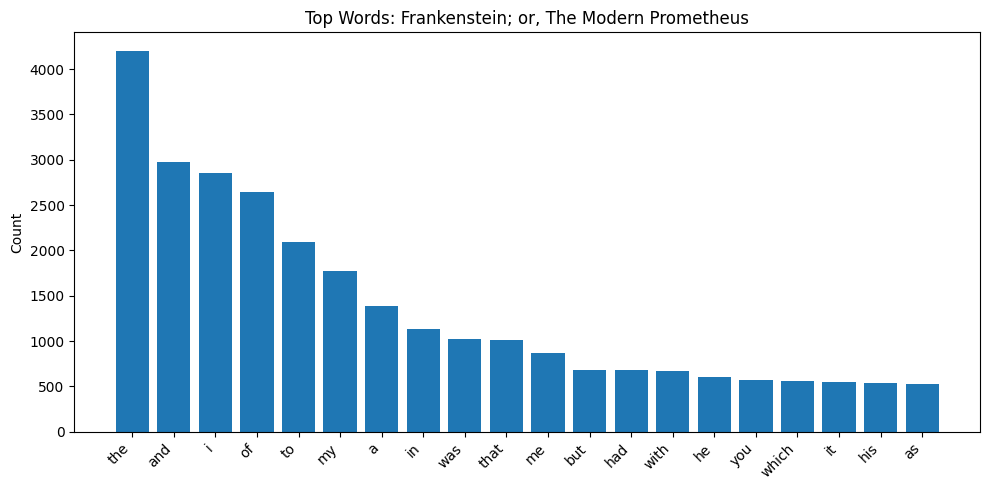

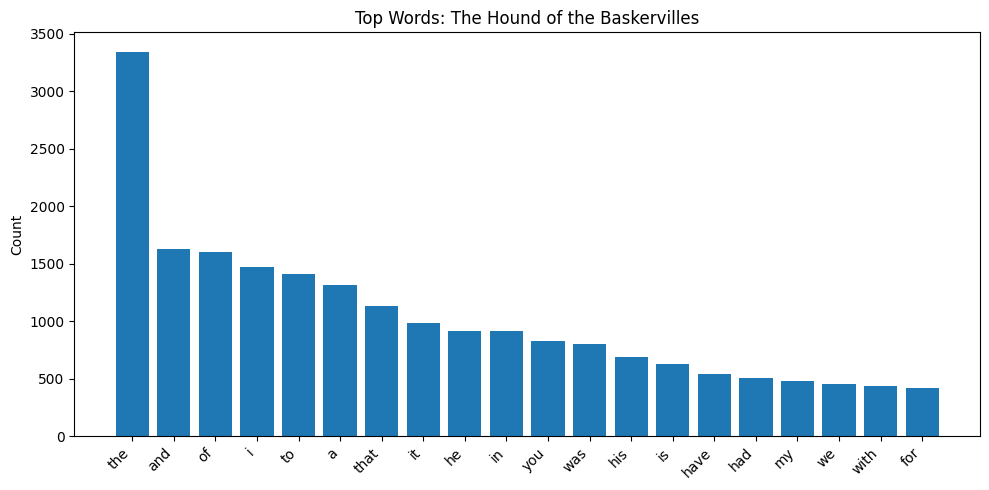

Done. CSVs/plots (top-20) are saved under: outputs/


In [3]:
# MiniProject1: Doyle x2 and Shelley x1
# -------------------------------------------------------
# Outputs printed:
#   Compare Same Author: The Adventures of Sherlock Holmes vs The Hound of the Baskervilles
#   Words more common in 'The Adventures of Sherlock Holmes':
#   <Word | Freq1 | Freq2 | Difference>
#   Words more common in 'The Hound of the Baskervilles':
#   <...>
#
# Dependencies: requests, pandas, numpy, matplotlib (plots optional)
#   pip install requests pandas numpy matplotlib

import os
import re
import requests
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt


BOOKS = {
    "doyle_adventures": {
        "title": "The Adventures of Sherlock Holmes",
        "url": "https://www.gutenberg.org/ebooks/1661.txt.utf-8",
    },
    "doyle_baskervilles": {
        "title": "The Hound of the Baskervilles",
        "url": "https://www.gutenberg.org/ebooks/2852.txt.utf-8",
    },
    "shelley_frankenstein": {
        "title": "Frankenstein; or, The Modern Prometheus",
        "url": "https://www.gutenberg.org/ebooks/84.txt.utf-8",
    },
}

# Optional: if you have local .txt files (UTF-8) set them here:
LOCAL_FILES = {
    # "doyle_adventures": "/path/to/1661.txt.utf-8",
    # "doyle_baskervilles": "/path/to/2852.txt.utf-8",
    # "shelley_frankenstein": "/path/to/84.txt.utf-8",
}

OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------
# Helpers
# ----------------------------
def fetch_text(key, url):
    """Fetch raw text from local file (if provided) or Project Gutenberg."""
    if key in LOCAL_FILES and os.path.exists(LOCAL_FILES[key]):
        with open(LOCAL_FILES[key], "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    resp.encoding = "utf-8"
    return resp.text

def strip_gutenberg_boilerplate(text):
    """Remove Gutenberg header/footer using START/END markers when present."""
    start = re.search(r"\*\*\* START OF.*? \*\*\*", text, flags=re.IGNORECASE)
    end   = re.search(r"\*\*\* END OF.*? \*\*\*", text, flags=re.IGNORECASE)
    if start and end and end.start() > start.end():
        return text[start.end():end.start()]
    # Fallback: crude trim if markers missing
    lines = text.splitlines()
    return "\n".join(lines[1000:-300]) if len(lines) > 1500 else text

def tokenize_keep_function_words(text):
    """
    Lowercase, keep apostrophes, drop non-letters (except apostrophes), split on whitespace.
    IMPORTANT: We KEEP stopwords and 1-char tokens to match the example style.
    """
    text = text.replace("—", " ").replace("–", " ").replace("’", "'").lower()
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

def counts(tokens):
    """Return Counter and total token count."""
    c = Counter(tokens)
    n = sum(c.values())
    return c, n

def top_words_table(c1, c2, topn=10):
    """
    Build two tables:
      - words more common in corpus1 (c1 - c2), topn by absolute difference
      - words more common in corpus2 (c2 - c1), topn by absolute difference
    Uses RAW COUNTS to mimic the sample output.
    """
    vocab = set(c1) | set(c2)
    rows_1 = []
    rows_2 = []
    for w in vocab:
        f1 = c1.get(w, 0)
        f2 = c2.get(w, 0)
        diff = f1 - f2
        if diff > 0:
            rows_1.append((w, f1, f2, diff))
        elif diff < 0:
            rows_2.append((w, f1, f2, diff))
    df1 = pd.DataFrame(rows_1, columns=["Word", "Freq1", "Freq2", "Difference"]).sort_values("Difference", ascending=False).head(topn)
    df2 = pd.DataFrame(rows_2, columns=["Word", "Freq1", "Freq2", "Difference"]).sort_values("Difference", ascending=True).head(topn)
    # For the 'more common in corpus2' table, present a positive Difference column by flipping sign for readability.
    if not df2.empty:
        df2 = df2.assign(Difference=(-df2["Difference"]))
        df2 = df2[["Word", "Freq1", "Freq2", "Difference"]]
    return df1, df2

def print_block_compare(title_a, title_b, c_a, n_a, c_b, n_b, topn=10, do_plots=True):
    """Print the 'like this' comparison block and show/save bar plots of top words."""
    print(f"Compare: {title_a} vs {title_b}")
    df_more_in_a, df_more_in_b = top_words_table(c_a, c_b, topn=topn)

    print(f"Words more common in '{title_a}':")
    print(df_more_in_a.to_string(index=False))
    print()
    print(f"Words more common in '{title_b}':")
    print(df_more_in_b.to_string(index=False))
    print()

    # Extra Credit: single-word analysis for 'would'
    word = "would"
    pa = c_a.get(word, 0) / max(n_a, 1)
    pb = c_b.get(word, 0) / max(n_b, 1)
    print("Extra Credit")
    print(f"'{word}' in {title_a}: count={c_a.get(word, 0)}, prob={pa:.5f}")
    print(f"'{word}' in {title_b}: count={c_b.get(word, 0)}, prob={pb:.5f}")
    print("\n")

    # Show plots on screen (and also save)
    if do_plots:
        for (counts, title, fname) in [
            (c_a, title_a, f"{slugify(title_a)}_top20.png"),
            (c_b, title_b, f"{slugify(title_b)}_top20.png"),
        ]:
            top = counts.most_common(20)
            if not top:
                continue
            words, vals = zip(*top)
            plt.figure(figsize=(10, 5))
            plt.bar(range(len(words)), vals)
            plt.xticks(range(len(words)), words, rotation=45, ha="right")
            plt.ylabel("Count")
            plt.title(f"Top Words: {title}")
            plt.tight_layout()
            # Save first, then display on screen
            plt.savefig(os.path.join(OUTDIR, fname), dpi=150)
            plt.show()
            plt.close()


    # Optional simple top-20 bar plots (saved)
    if do_plots:
        for (counts, title, fname) in [
            (c_a, title_a, f"{slugify(title_a)}_top20.png"),
            (c_b, title_b, f"{slugify(title_b)}_top20.png"),
        ]:
            top = counts.most_common(20)
            if not top:
                continue
            words, vals = zip(*top)
            plt.figure(figsize=(10, 5))
            plt.bar(range(len(words)), vals)
            plt.xticks(range(len(words)), words, rotation=45, ha="right")
            plt.ylabel("Count")
            plt.title(f"Top Words: {title}")
            plt.tight_layout()
            plt.savefig(os.path.join(OUTDIR, fname), dpi=150)
            plt.close()

def slugify(s):
    return re.sub(r"[^a-z0-9]+", "-", s.lower()).strip("-")

# ----------------------------
# Main
# ----------------------------
def main():
    # 1) Fetch & tokenize all three books
    corpora = {}
    for key, meta in BOOKS.items():
        raw = fetch_text(key, meta["url"])
        core = strip_gutenberg_boilerplate(raw)
        toks = tokenize_keep_function_words(core)
        c, n = counts(toks)
        corpora[key] = {"title": meta["title"], "counts": c, "n": n}

    A = corpora["doyle_adventures"]
    B = corpora["doyle_baskervilles"]
    S = corpora["shelley_frankenstein"]

    # 2) SAME-AUTHOR comparison (Doyle)
    print(f"Compare Same Author: {A['title']} vs {B['title']}")
    print_block_compare(A["title"], B["title"], A["counts"], A["n"], B["counts"], B["n"], topn=10, do_plots=True)

    # 3) CROSS-AUTHOR comparisons: Shelley vs each Doyle
    print(f"Compare Different Authors: {S['title']} vs {A['title']}")
    print_block_compare(S["title"], A["title"], S["counts"], S["n"], A["counts"], A["n"], topn=10, do_plots=True)

    print(f"Compare Different Authors: {S['title']} vs {B['title']}")
    print_block_compare(S["title"], B["title"], S["counts"], S["n"], B["counts"], B["n"], topn=10, do_plots=True)

    print(f"Done. CSVs/plots (top-20) are saved under: {OUTDIR}/")

if __name__ == "__main__":
    main()
